# Jupyter Notebook
# Lecture 20 - PCA 


##ANSWER## 

### Instructor notes:

- notes from Fall 2023..... AAAAAAAH something goes wrong when you shuffle the data and I don't know what it is!

### older notes

- For next year, have them plot the PC1,PC2 plot way earlier, lots of questions about the "which quadrant?" question.
- Also update the moving point around plot to also show where the point lands in the PC plot to help with them understanding that the point gets drawn in a new location.

Penguin part, used some content from here: https://cmdlinetips.com/2020/06/principal-component-analysis-with-penguins-data-in-python/

Made use of this python translation of the lab: https://www.science.smith.edu/~jcrouser/SDS293/labs/lab10-py.html

and
https://www.science.smith.edu/~jcrouser/SDS293/labs/lab11-py.html

Note: needed to update the `Hitters.csv` file I found online to have the label `Player` in the first column


In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time

import seaborn as sns

# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# 1. PCA on Penguins
![Palmer Penguins Picture](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)

*Artwork by @allison_horst*


For this lab, we are going to again use the <a href = "https://allisonhorst.github.io/palmerpenguins/">Palmer Penguins</a> data set by Allison Horst, Alison Hill, and Kristen Gorman. You should have done this in a previous notebook, but if you don't have the package installed to get the data, you can run 
```
pip install palmerpenguins
```
to have access to the data. 

In [2]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins = penguins.dropna()

#Shuffle the data
# penguins = penguins.sample(frac=1)
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Before we get to the full version, let's just take a look at two of the columns: flipper length and bill length. A nice thing we can do is to also color the data by which species label the data point has. 

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

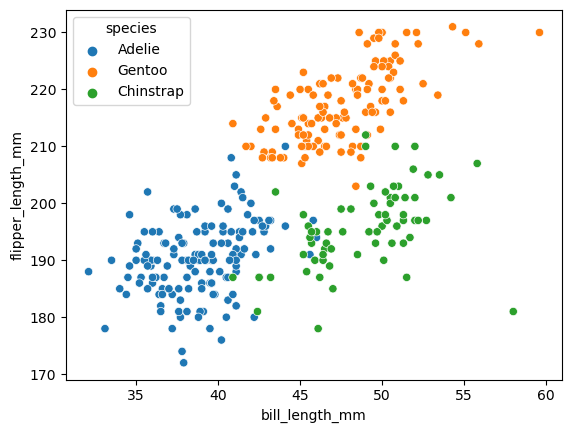

In [3]:
sns.scatterplot(x = penguins.bill_length_mm, 
                y = penguins.flipper_length_mm, 
                hue = penguins.species)

Before we get to it, we're going to just work with the columns that are numeric.  

In [4]:
penguins_num = penguins.select_dtypes(np.number)
penguins_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007
1,39.5,17.4,186.0,3800.0,2007
2,40.3,18.0,195.0,3250.0,2007
4,36.7,19.3,193.0,3450.0,2007
5,39.3,20.6,190.0,3650.0,2007


We will also use mean centered data to make the visualization easier (meaning shifting our data to have mean 0 in every column, and have standard deviation 1). 

In [5]:
p_normalized = (penguins_num - penguins_num.mean())/penguins_num.std()
p_normalized.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,-0.894695,0.779559,-1.424608,-0.567621,-1.281813
1,-0.821552,0.119404,-1.067867,-0.505525,-1.281813
2,-0.675264,0.424091,-0.425733,-1.188572,-1.281813
4,-1.333559,1.084246,-0.568429,-0.940192,-1.281813
5,-0.858123,1.744400,-0.782474,-0.691811,-1.281813


## PCA with just two input columns

To try to draw pictures similar to what we just saw on the slides, we'll first focus on two of the columns. 

In [6]:
penguins_subset2 = p_normalized[['bill_length_mm', 'flipper_length_mm']]
penguins_subset2

,bill_length_mm,flipper_length_mm
0,-0.894695,-1.424608
1,-0.821552,-1.067867
2,-0.675264,-0.425733
4,-1.333559,-0.568429
5,-0.858123,-0.782474
...,...,...
339,2.159064,0.430446
340,-0.090112,0.073705
341,1.025333,-0.568429
342,1.244765,0.644491


We run PCA using the `PCA` command from `scikitlearn`.

In [7]:
from sklearn.decomposition import PCA

In [8]:
# Set up the PCA object
pca = PCA(n_components=2)

# Fit it using our data
pca.fit(penguins_subset2.values)

PCA(n_components=2)

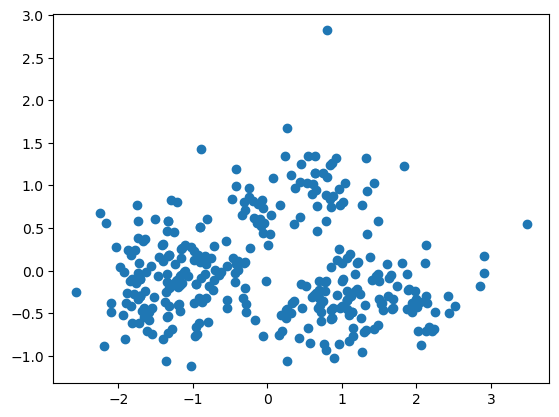

In [9]:
pca_df = pca.fit_transform(penguins_subset2.values)
plt.scatter(pca_df[:,0], pca_df[:,1])

The `pca.components_` store information about the lines we are going to project our data onto. Specifically, each row gives us one of these lines.

In [10]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

(-2.4261469084390344,
 3.1053642574684943,
 -2.2772189966421617,
 3.254292169265367)

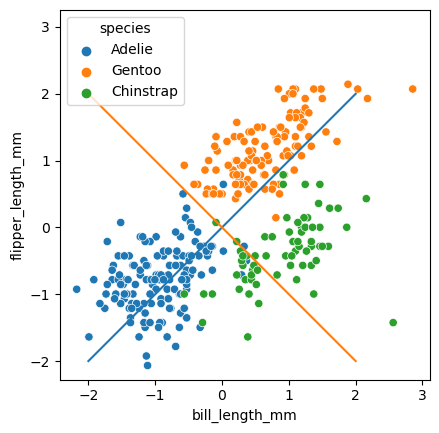

In [11]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)

for i, comp in enumerate(pca.components_):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))
    
plt.axis('square')

A common way to look at the relative importance of the PC's is to draw these components as vectors with length based on the explained variance. 

In [12]:
pca.explained_variance_

array([1.65309564, 0.34690436])

(-2.4261469084390344,
 3.1053642574684943,
 -2.2772189966421617,
 3.254292169265367)

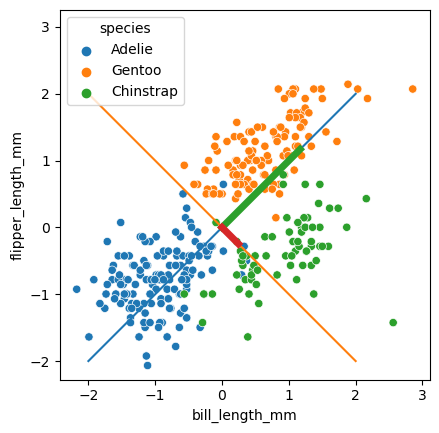

In [13]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)

for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))
    
    comp = comp * var  # scale component by its variance explanation power
    plt.plot(
        [0, comp[0]],
        [0, comp[1]],
        label=f"Component {i}",
        linewidth=5,
        color=f"C{i + 2}",
    )

plt.axis('square')

The next important part are the PC's, which we can get from the `pca` object as follows. I'm going to put them in a dataframe to make drawing and visualization easier. Basically, $PC_1$ is our $Z_1$ in the slides, and $PC_2$ is the $Z_2$.

In [14]:
# The transform function takes in bill,flipper data points, 
# and returns a PC1,PC2 coordinate for each one. 
penguins_pca = pca.fit_transform(penguins_subset2)
penguins_pca = pd.DataFrame(data = penguins_pca, columns = ['PC1', 'PC2'])
penguins_pca.shape

(333, 2)

In [15]:
penguins.species

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object

This is the scatterplot of the data points transformed into the PC space. 

<Axes: xlabel='PC1', ylabel='PC2'>

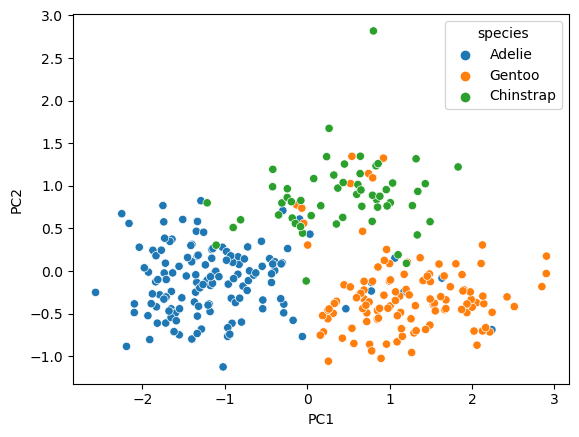

In [16]:
sns.scatterplot(data = penguins_pca, x = 'PC1', y = 'PC2',hue = penguins.species)

&#9989; **<font color=red>Do this:</font>** What are the PC coordinates for the first data point (index 0)?  Which quadrant would this point be drawn in? 


In [17]:
# Your answer here


In [18]:
##ANSWER## 
penguins_pca.iloc[0]
# This would be in the 2nd quadrant (up left)

PC1   -1.639995
PC2    0.374705
Name: 0, dtype: float64


The PC's can be thought of as how far along their associated line the point would be projected. Here's one way to draw all the projections. 

(-2.4261469084390344,
 3.1053642574684943,
 -2.2932134979887167,
 3.238297667918812)

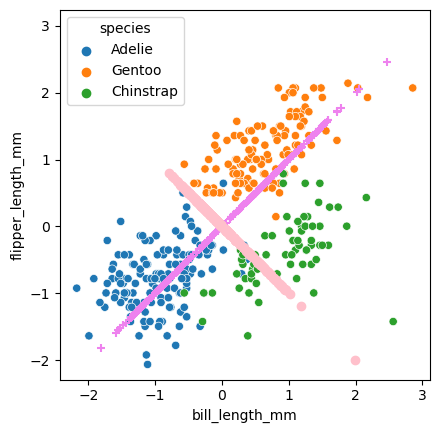

In [19]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)


# Show points projected onto the 1st PC line
X1 = penguins_pca.PC1*pca.components_[0,0]
Y1 = penguins_pca.PC1*pca.components_[0,1]

plt.scatter(X1,Y1, marker = '+', color = 'violet')


# Show points projected onto the 2st PC line
X2 = penguins_pca.PC2*pca.components_[1,0]
Y2 = penguins_pca.PC2*pca.components_[1,1]

plt.scatter(X2,Y2, marker = 'o', color = 'pink')
plt.axis('square')

Below is code that emphasizes the projected points. 

&#9989; **<font color=red>Do this:</font>** the value of `index` below is just picking out a different point in our data set.  Mess around with this number. How do the X and star points move around as you change `index`? 

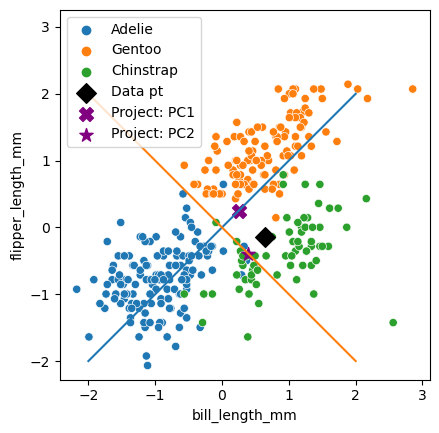

In [20]:
sns.scatterplot(data = penguins_subset2, 
                x = 'bill_length_mm', 
                y = 'flipper_length_mm', 
                hue = penguins.species)
plt.axis('square')

for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    slope = comp[1]/comp[0]
    plt.plot(np.array([-2,2]), slope*np.array([-2,2]))

#===========
# Emphasize one point and its projections
#===========

index = 300 #<---------- play with this!

# Here's one data point
plt.scatter([penguins_subset2.iloc[index,0]],
            [penguins_subset2.iloc[index,1]], 
            marker = 'D', color = 'black', s = 100, label = 'Data pt')

# Here's the projection of that point on PC1 (X shape)
plt.scatter([X1[index]], [Y1[index]], 
           marker = 'X', color = 'purple', s = 100, label = 'Project: PC1')

# And here's the projection of that point on PC2 (star)
plt.scatter([X2[index]], [Y2[index]], 
           marker = '*', color = 'purple', s = 100, label = 'Project: PC2')

plt.legend()

Everything we just did is great for understanding what the PCA is doing, but in reality, we're usually going to be looking at the data in the transformed space. 

&#9989; **<font color=red>Do this:</font>** Make a scatter plot of PC1 and PC2. Color the points by `penguins.species`. What do you notice about how the points have moved from the (`bill`, `flipper`) scatter plot? 

In [21]:
# Your code here

<Axes: xlabel='PC1', ylabel='PC2'>

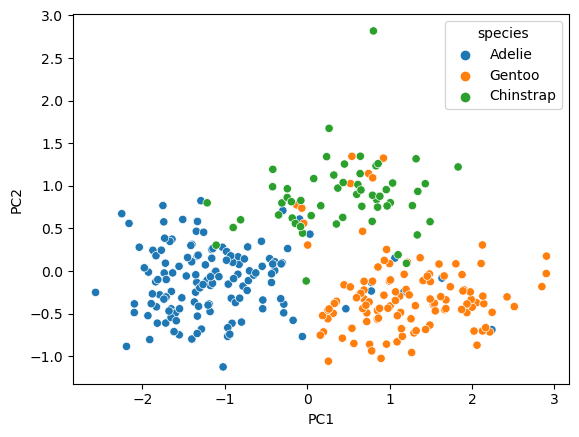

In [22]:
##ANSWER##

# Instead plot in PC1, PC2 plane 
sns.scatterplot(data = penguins_pca, x = 'PC1', y = 'PC2', hue = penguins.species)

# The points appear to have been flipped since the second PC is 
# pointing down, so now the green points are on top. 

## Penguins PCA with all columns

We used only two columns above for visualization, but we can instead use all the input columns to run our PCA. 

In [23]:
penguins_num.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007
1,39.5,17.4,186.0,3800.0,2007
2,40.3,18.0,195.0,3250.0,2007
4,36.7,19.3,193.0,3450.0,2007
5,39.3,20.6,190.0,3650.0,2007


In [24]:
pca = PCA(n_components=4)
penguins_pca_all = pca.fit_transform(penguins_num)
penguins_pca_all = pd.DataFrame(data = penguins_pca_all, 
                                columns = ['PC1', 'PC2', 'PC3', 'PC4'])
penguins_pca_all

,PC1,PC2,PC3,PC4
0,-457.325096,13.376298,1.247904,-0.376474
1,-407.252228,9.205245,-0.032667,-1.090217
2,-957.044699,-8.128321,-2.491467,0.720823
3,-757.115824,-1.838910,-4.880569,2.073668
4,-557.177325,3.416994,-1.129267,2.629297
...,...,...,...,...
328,-206.895442,-12.507424,9.424523,2.201716
329,-806.944216,-13.443905,-1.490242,1.436737
330,-432.103210,-0.999033,7.386135,-0.375741
331,-106.881363,-12.241310,3.792123,2.298703


&#9989; **<font color=red>Do this:</font>** Make a scatter plot of PC1 and PC2 using this new model, and again color the points by `penguins.species`. What do you notice about how the PC plot has changed from the previous setting? 

In [25]:
# your code here

<Axes: xlabel='PC1', ylabel='PC2'>

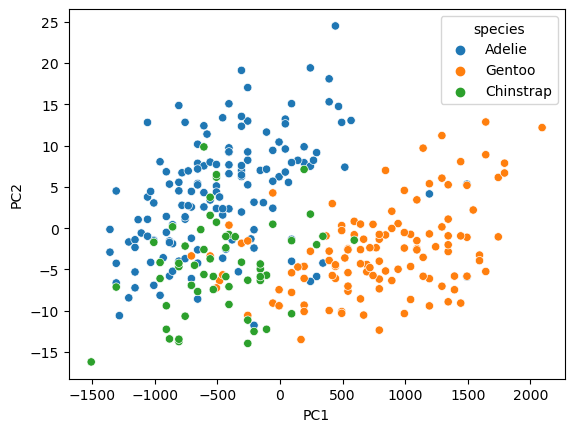

In [26]:
##ANSWER##
sns.scatterplot(data = penguins_pca_all, x = 'PC1', y = 'PC2', hue = penguins.species)

# More overlap, the projection has changed.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [29]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


Myfilename CMSE381-Lec19-Ch6_3-PCA-INSTRUCTOR copy.ipynb


CMSE381-Lec19_Ch6_3_PCA_INSTRUCTOR_copy.ipynb


Validating Notebook ./CMSE381-Lec19_Ch6_3_PCA_INSTRUCTOR_copy.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


7

In [28]:
##ANSWER## 

# Here's a graph of the number of non-zero entries for different choices of alpha

lasso = Lasso(max_iter = 10000, normalize = True)
nonzero = []

for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(X_train, y_train) 
    nonzero.append(np.count_nonzero(lasso.coef_)) #Counts the number of non-0 entries
    



plt.title('Number of non-zero entries')

plt.plot(alphas,nonzero)
ax=plt.gca()
ax.set_xscale('log')




NameError: name 'Lasso' is not defined

In [105]:
##ANSWER##
penguins3 = penguins_num.iloc[:,:3]

pca = PCA(n_components=2)
penguins_pca3 = pca.fit_transform(penguins3)
penguins_pca3 = pd.DataFrame(data = penguins_pca3, 
                                columns = ['PC1', 'PC2'])
penguins_pca3.head()

,PC1,PC2
0,-8.971647,8.733455
1,15.553589,-4.893617
2,-6.752518,-0.525908
3,-9.758777,-4.668310
4,0.789735,-0.606585


In [106]:
##ANSWER##
pca.components_

array([[ 0.26583918, -0.07693674,  0.96094238],
       [ 0.95753345,  0.13649137, -0.2539681 ]])